In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc,
    roc_auc_score
)

In [2]:
# Setup
OUTDIR = "img/"
os.makedirs(OUTDIR, exist_ok=True)

def savefig(name):
    path = os.path.join(OUTDIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved:", path)

RNG = 42
np.random.seed(RNG)

In [3]:
# Balanced-"ish" binary classification
X, y = make_classification(
    n_samples=2000, n_features=10, n_informative=6, n_redundant=2,
    n_clusters_per_class=2, weights=[0.5, 0.5], class_sep=1.2,
    random_state=RNG
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RNG
)

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, solver="lbfgs")
)
clf.fit(X_train, y_train)

# Probabilities for positive class
y_score = clf.predict_proba(X_test)[:, 1]
y_pred = (y_score >= 0.5).astype(int)

Saved: img/learning_curve.png


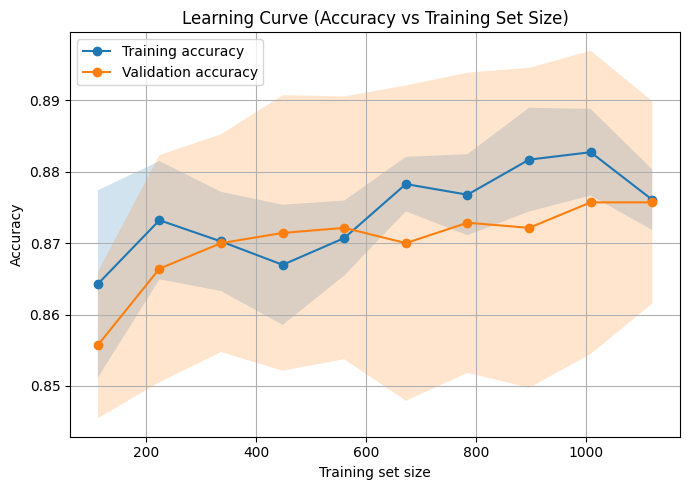

In [4]:
# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    clf, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG),
    scoring="accuracy",
    n_jobs=None
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training accuracy")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
plt.plot(train_sizes, val_mean, marker="o", label="Validation accuracy")
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.2)
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Accuracy vs Training Set Size)")
plt.legend()
plt.grid(True)
savefig("learning_curve.png")
plt.show()

Saved: img/confusion_matrix_binary.png


<Figure size 500x400 with 0 Axes>

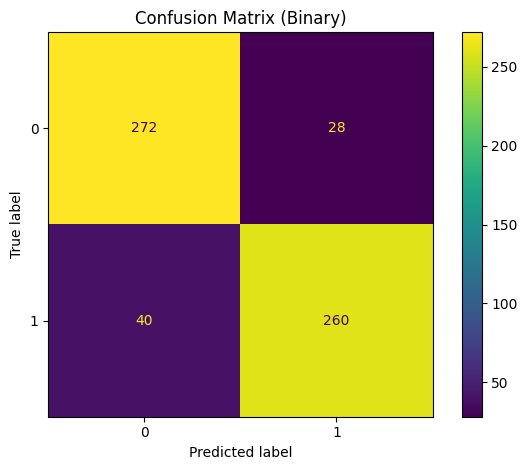

In [5]:
# Binary confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

plt.figure(figsize=(5, 4))
disp.plot(values_format="d")
plt.title("Confusion Matrix (Binary)")
savefig("confusion_matrix_binary.png")
plt.show()


Saved: img/threshold_tradeoff.png


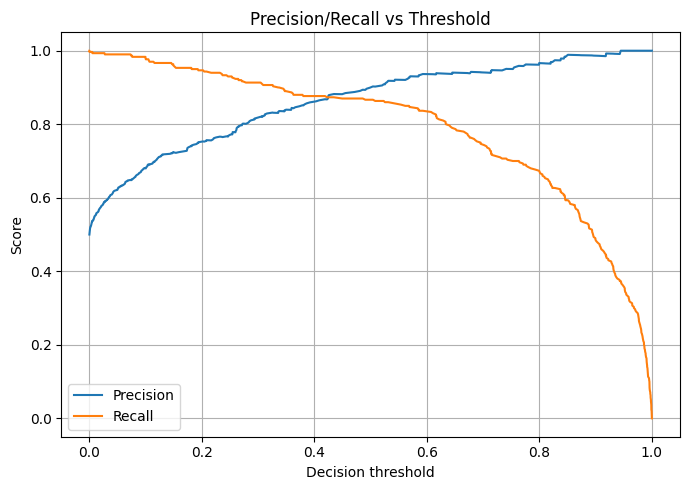

In [6]:
# Precision/Recall vs Threshold tradeoff plot
prec, rec, thresh = precision_recall_curve(y_test, y_score)

# precision_recall_curve returns thresholds of length n-1
# align arrays for plotting
thresh_plot = np.r_[thresh, 1.0]  # pad to same length for plotting

plt.figure(figsize=(7, 5))
plt.plot(thresh_plot, prec, label="Precision")
plt.plot(thresh_plot, rec, label="Recall")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Precision/Recall vs Threshold")
plt.legend()
plt.grid(True)
savefig("threshold_tradeoff.png")
plt.show()


Saved: img/pr_curve.png


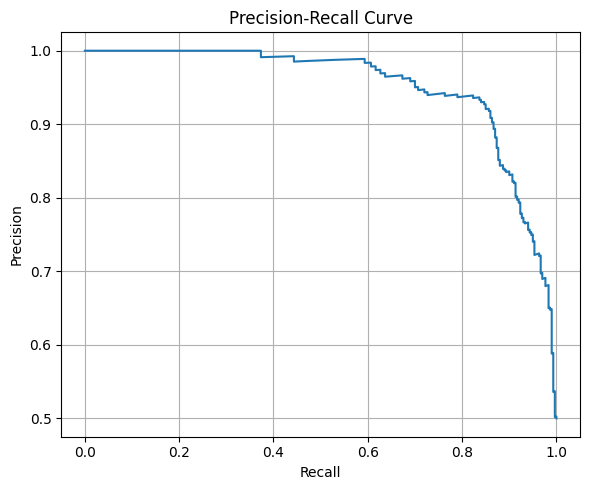

PR AUC (trapezoid): 0.9515102147890271


In [7]:
# Precision vs Recall (PR) Curve
plt.figure(figsize=(6, 5))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
savefig("pr_curve.png")
plt.show()

# PR AUC (area under PR curve)
pr_auc = auc(rec, prec)
print("PR AUC (trapezoid):", pr_auc)

Saved: img/roc_curve_2.png


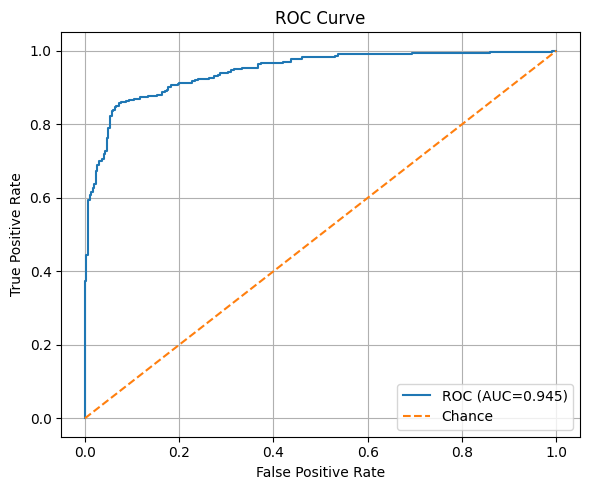

ROC AUC: 0.9445444444444444


In [8]:
# ROC curve + AUC
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
savefig("roc_curve_2.png")
plt.show()

print("ROC AUC:", roc_auc)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Saved: img/multiclass_roc_ovr.png


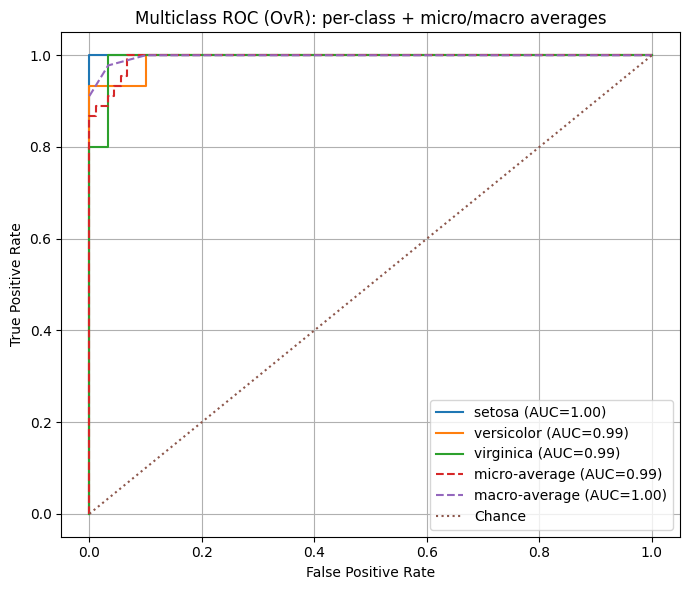

Micro AUC: 0.9938271604938271 Macro AUC: 0.9974074074074074


In [9]:
# Multiclass ROC (OvR) on Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
class_names = iris.target_names
n_classes = len(np.unique(y_iris))

Xtr, Xte, ytr, yte = train_test_split(
    X_iris, y_iris, test_size=0.3, stratify=y_iris, random_state=RNG
)

# Multinomial logistic regression
mc_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, multi_class="auto", solver="lbfgs")
)
mc_clf.fit(Xtr, ytr)

# Binarize labels for OvR ROC
yte_bin = label_binarize(yte, classes=np.arange(n_classes))
y_score_mc = mc_clf.predict_proba(Xte)  # shape (n_samples, n_classes)

# Compute ROC curve and AUC for each class
fpr_dict, tpr_dict, auc_dict = {}, {}, {}
for i in range(n_classes):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(yte_bin[:, i], y_score_mc[:, i])
    auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

# Micro-average
fpr_micro, tpr_micro, _ = roc_curve(yte_bin.ravel(), y_score_mc.ravel())
auc_micro = auc(fpr_micro, tpr_micro)

# Macro-average: average TPR at common FPR points
all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
mean_tpr /= n_classes
auc_macro = auc(all_fpr, mean_tpr)

plt.figure(figsize=(7, 6))

# Plot per-class ROC
for i in range(n_classes):
    plt.plot(fpr_dict[i], tpr_dict[i], label=f"{class_names[i]} (AUC={auc_dict[i]:.2f})")

# Plot micro + macro
plt.plot(fpr_micro, tpr_micro, linestyle="--", label=f"micro-average (AUC={auc_micro:.2f})")
plt.plot(all_fpr, mean_tpr, linestyle="--", label=f"macro-average (AUC={auc_macro:.2f})")

plt.plot([0, 1], [0, 1], linestyle=":", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC (OvR): per-class + micro/macro averages")
plt.legend()
plt.grid(True)
savefig("multiclass_roc_ovr.png")
plt.show()

print("Micro AUC:", auc_micro, "Macro AUC:", auc_macro)

## Interactive Controls\nUse the widget panel below to explore parameters live inside JupyterLite.\n

In [ ]:
# INTERACTIVE_WIDGET_SECTION\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport ipywidgets as widgets\n\ndef _interactive_demo(freq=1.0, amp=1.0, phase=0.0):\n    x=np.linspace(-10,10,500)\n    y=amp*np.sin(freq*x+phase)\n    plt.figure(figsize=(8,4))\n    plt.plot(x,y,lw=2)\n    plt.grid(True)\n    plt.title('Interactive Demo Panel')\n    plt.show()\n\nwidgets.interact(_interactive_demo,\n    freq=widgets.FloatSlider(value=1.0,min=0.1,max=5.0,step=0.1),\n    amp=widgets.FloatSlider(value=1.0,min=0.1,max=3.0,step=0.1),\n    phase=widgets.FloatSlider(value=0.0,min=-3.14,max=3.14,step=0.1))\n